# 使用Face-Recognition套件進行臉部追蹤
### 程式修改自 [face-recognition GitHub Examples](https://github.com/ageitgey/face_recognition)

## 載入相關套件

In [1]:
# 安裝套件： pip install face-recognition
# 載入相關套件
import subprocess

import cv2
import face_recognition
import matplotlib.pyplot as plt
from IPython import display

/Users/rikenmi/Work/study/python/PyTorch_Book/.venv/lib/python3.12/site-packages/face_recognition_models/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## 載入並顯示圖檔

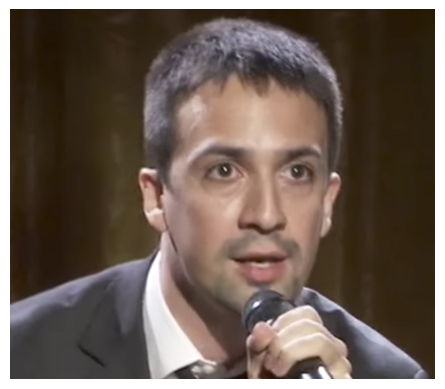

In [2]:
# 載入圖檔
image_file = "images_face/lin-manuel-miranda.png"
image = plt.imread(image_file)

# 顯示圖像
plt.imshow(image)
plt.axis('off')
plt.show()

## 載入影片檔

In [3]:
# 載入影片檔
input_path = "images_face/short_hamilton_clip.mp4"
input_movie = cv2.VideoCapture(input_path)
length = int(input_movie.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'影片幀數：{length}')

影片幀數：275


In [4]:
# 指定輸出檔名
fourcc = cv2.VideoWriter.fourcc(*'XVID')
output_path = 'images_face/output.avi'
# 每秒幀數(fps):29.97，影片解析度(Frame Size)：(640, 360)
output_movie = cv2.VideoWriter(output_path, fourcc, 29.97, (640, 360))

## 載入要辨識的圖像

In [5]:
# 載入要辨識的圖像
image_file = 'lin-manuel-miranda.png'  # 美國歌手
lmm_image = face_recognition.load_image_file("images_face/" + image_file)
# 取得圖像編碼
lmm_face_encoding = face_recognition.face_encodings(lmm_image)[0]

# obama
image_file = 'obama.jpg'  # 美國總統
obama_image = face_recognition.load_image_file("images_face/" + image_file)
# 取得圖像編碼
obama_face_encoding = face_recognition.face_encodings(obama_image)[0]

# 設定陣列
known_faces = [lmm_face_encoding, obama_face_encoding]

# 目標名稱
known_face_names = ['lin-manuel-miranda', 'obama']

## 比對臉部並存檔

In [6]:
# 變數初始化
face_locations = []  # 臉部位置
face_encodings = []  # 臉部編碼
face_names = []  # 臉部名稱
frame_number = 0  # 幀數

In [ ]:
# 偵測臉部並寫入輸出檔
while True:
    # 讀取一幀影像
    ret, frame = input_movie.read()
    frame_number += 1

    # 影片播放結束，即跳出迴圈
    if not ret:
        break

    # 將 BGR 色系轉為 RGB 色系
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # 找出臉部位置
    face_locations = face_recognition.face_locations(rgb_frame)
    if len(face_locations):
        print(face_locations)
    # 編碼
    face_encodings = face_recognition.face_encodings(rgb_frame, face_locations)

    # 比對臉部
    face_names = []
    for face_encoding in face_encodings:
        # 比對臉部編碼是否與圖檔符合
        match = face_recognition.compare_faces(known_faces, face_encoding, tolerance=0.50)

        # 找出符合臉部的名稱
        name = None
        for i in range(len(match)):
            if match[i]:
                name = known_face_names[i]
                break

        face_names.append(name)

    # 輸出影片標記臉部位置及名稱
    for (top, right, bottom, left), name in zip(face_locations, face_names):
        if not name:
            continue

        # 加框
        cv2.rectangle(frame, (left, top), (right, bottom), (0, 0, 255), 2)

        # 標記名稱
        cv2.rectangle(frame, (left, bottom - 25), (right, bottom), (0, 0, 255), cv2.FILLED)
        font = cv2.FONT_HERSHEY_DUPLEX
        cv2.putText(frame, name, (left + 6, bottom - 6), font, 0.5, (255, 255, 255), 1)

    # 將每一幀影像存檔
    print(f"Writing frame {frame_number} / {length}")
    output_movie.write(frame)

# 關閉輸入檔與輸出檔
input_movie.release()
output_movie.release()
# 關閉所有視窗
cv2.destroyAllWindows()

In [8]:
# 轉碼為 H.264 / yuv420p 的 mp4，才能在瀏覽器與 VSCode 中正常播放
final_output_path = 'images_face/output.mp4'
subprocess.run(
    [
        'ffmpeg', '-y', '-i', output_path,
        '-vcodec', 'libx264', '-pix_fmt', 'yuv420p',
        final_output_path,
    ],
    check=True,
)

ffmpeg version 8.1.2 Copyright (c) 2000-2026 the FFmpeg developers
  built with Apple clang version 21.0.0 (clang-2100.0.123.102)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.1.2_1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gpl --enable-libsvtav1 --enable-libopus --enable-libx264 --enable-libmp3lame --enable-libdav1d --enable-libvmaf --enable-libvpx --enable-libx265 --enable-openssl --enable-videotoolbox --enable-audiotoolbox --enable-neon
  libavutil      60. 26.102 / 60. 26.102
  libavcodec     62. 28.102 / 62. 28.102
  libavformat    62. 12.102 / 62. 12.102
  libavdevice    62.  3.102 / 62.  3.102
  libavfilter    11. 14.102 / 11. 14.102
  libswscale      9.  5.102 /  9.  5.102
  libswresample   6.  3.102 /  6.  3.102
Input #0, avi, from 'images_face/output.avi':
  Metadata:
    software        : Lavf60.3.100
  Duration: 00:00:09.18, start: 0.000000, bitrate: 1326 kb/s
  Stream #0:0: Video: mpeg4 

CompletedProcess(args=['ffmpeg', '-y', '-i', 'images_face/output.avi', '-vcodec', 'libx264', '-pix_fmt', 'yuv420p', 'images_face/output.mp4'], returncode=0)

In [9]:
display.Video(final_output_path, width=640)